# 06 — The geometric model: four scores + fault-mode geometry
Position ("how far?"), velocity ("how fast?"), net displacement ("how much life?"),
direction ("which fault mode?") — all from one PCA fitted on healthy cycles.

Design rationale (validated in a pilot study):
- velocity on the **smoothed** latent (raw finite differences = noise: AUROC 0.54 vs 0.81);
- **net displacement, not arc length**: under stationary noise E[arc_t] ≈ c0·t (an age
  counter: corr(arc, cycle)=0.996 on healthy data), while ||Σε|| grows only as √t.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.loaders import prepare, load, SENSORS, HEALTHY_RUL
from src.scores import GeometricModel, unit_directions
from src import metrics

In [2]:
rows = {}
models, data = {}, {}
for fd in ['FD001', 'FD004']:
    d = prepare(fd, seed=42); data[fd] = d
    gm = GeometricModel(n_components=3, w=10).fit(d['fit']); models[fd] = gm
    sc = gm.score(d['val'])
    for name, col in [('position', 'pos'), ('velocity', 'vel'), ('net displacement', 'net')]:
        rows[(fd, name)] = {p: metrics.auroc(sc[col], d['val'].rul, use_buffer=b)
                            for p, b in [('buffer', True), ('no-buffer', False)]}
    rows[(fd, 'spearman(net,RUL)')] = {'buffer': metrics.spearman_rul(sc['net'], d['val'].rul),
                                       'no-buffer': np.nan}
tab = pd.DataFrame(rows).T.round(3); tab.to_csv('../results/tables/06_scores.csv'); tab

buffer  no-buffer
FD001 position            0.995      0.953
      velocity            0.812      0.799
      net displacement    1.000      0.989
      spearman(net,RUL)  -0.864        NaN
FD004 position            0.998      0.979
      velocity            0.827      0.799
      net displacement    0.998      0.963
      spearman(net,RUL)  -0.808        NaN

## Why arc length was rejected

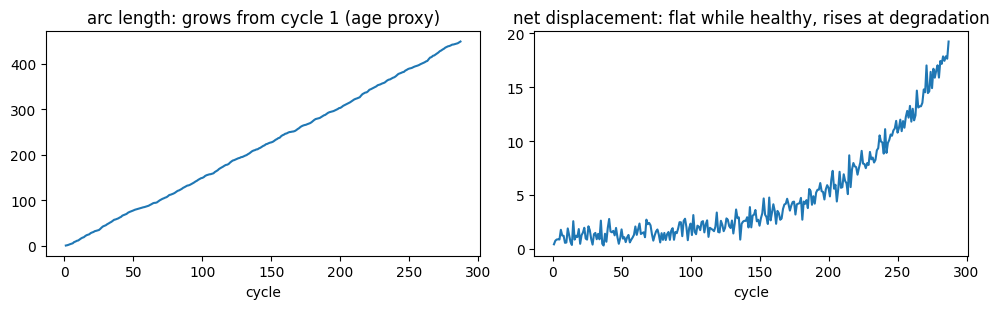

In [3]:
d, gm = data['FD001'], models['FD001']
g = d['val'][d['val'].unit == d['val'].unit.iloc[0]]
Z = gm.latent(g)
arc = np.concatenate([[0], np.cumsum(np.linalg.norm(np.diff(Z, axis=0), axis=1))])
net = np.linalg.norm(Z - Z[:10].mean(0), axis=1)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].plot(g.cycle, arc); ax[0].set(title='arc length: grows from cycle 1 (age proxy)', xlabel='cycle')
ax[1].plot(g.cycle, net); ax[1].set(title='net displacement: flat while healthy, rises at degradation', xlabel='cycle')
plt.tight_layout(); plt.savefig('../results/figures/06_arc_vs_net.png', dpi=120); plt.show()

In [4]:
# quantify on ALL healthy validation cycles: corr with cycle (age) should be ~0 for a health index
hv, arcs, nets, cycs = data['FD001']['val'], [], [], []
for u, g in hv.groupby('unit'):
    Z = gm.latent(g)
    a = np.concatenate([[0], np.cumsum(np.linalg.norm(np.diff(Z, axis=0), axis=1))])
    n = np.linalg.norm(Z - Z[:10].mean(0), axis=1)
    m = (g.rul > HEALTHY_RUL).values
    arcs.append(a[m]); nets.append(n[m]); cycs.append(g.cycle.values[m])
arcs, nets, cycs = map(np.concatenate, [arcs, nets, cycs])
print('healthy cycles only: corr(arc, cycle) = %.3f | corr(net, cycle) = %.3f' %
      (np.corrcoef(arcs, cycs)[0, 1], np.corrcoef(nets, cycs)[0, 1]))

healthy cycles only: corr(arc, cycle) = 0.996 | corr(net, cycle) = 0.568


## Fault-mode geometry: cluster-then-angle (FD001 → FD003)
FD003 units are NOT labeled by fault mode, so: cluster per-unit late-life directions
(KMeans, k=2), then measure angles. Never use the mean FD003 direction — it is a mixture.

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
gm1 = models['FD001']
tr3 = prepare('FD003', seed=42)   # same pipeline; directions need its own normalization
gm3in1 = gm1                       # project FD003 into the FD001 healthy space
# normalize FD003 with FD001 stats for a shared space: reuse FD001 normalizer
n1 = data['FD001']['normalizer']
t3 = load('FD003'); t3['regime'] = 0
t3n = n1.transform(t3)
D3, u3 = unit_directions(gm1, t3n)
D1, u1 = unit_directions(gm1, pd.concat([data['FD001'][k] for k in ['fit', 'cal', 'val']]))
km = KMeans(2, n_init=10, random_state=0).fit(D3)
c0, c1 = (c / np.linalg.norm(c) for c in km.cluster_centers_)
d1m = D1.mean(0); d1m /= np.linalg.norm(d1m)
print('FD003 clusters: sizes', np.bincount(km.labels_), '| cos(c0,c1) = %.2f' % (c0 @ c1))
print('cos(c0, FD001 dir) = %.2f | cos(c1, FD001 dir) = %.2f' % (c0 @ d1m, c1 @ d1m))
print('silhouette = %.2f' % silhouette_score(D3, km.labels_))

FD003 clusters: sizes [44 56] | cos(c0,c1) = -0.65
cos(c0, FD001 dir) = -0.60 | cos(c1, FD001 dir) = 1.00
silhouette = 0.82


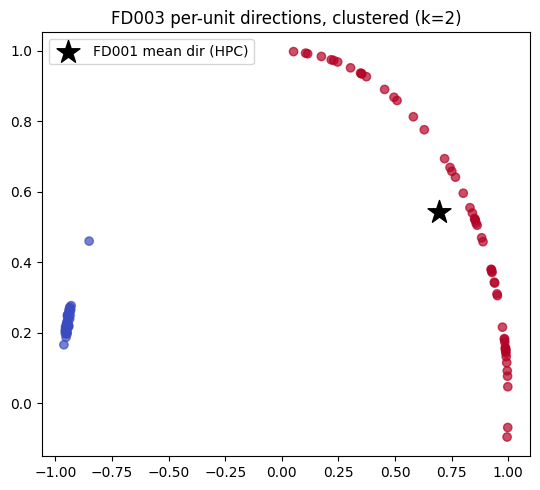

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(D3[:, 0], D3[:, 1], c=km.labels_, cmap='coolwarm', alpha=.7)
ax.scatter(*D1.mean(0)[:2], marker='*', s=300, c='k', label='FD001 mean dir (HPC)')
ax.set(title='FD003 per-unit directions, clustered (k=2)'); ax.legend()
plt.tight_layout(); plt.savefig('../results/figures/06_fault_modes.png', dpi=120); plt.show()

One cluster aligns with FD001's HPC direction (cos ≈ 1.0), the other points away
(cos < 0): **unsupervised fault-mode identification** — the main geometric result of the project.

## Score fusion + non-Gaussian check

In [7]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import NearestNeighbors
d = data['FD004']; gm = models['FD004']
sc_fit, sc_val = gm.score(d['fit']), gm.score(d['val'])
F = ['pos', 'vel', 'net']
iso = IsolationForest(n_estimators=200, random_state=0).fit(sc_fit.loc[d['fit'].rul > HEALTHY_RUL, F])
fus = -iso.score_samples(sc_val[F])
H = gm.latent(d['fit'][d['fit'].rul > HEALTHY_RUL])
nn = NearestNeighbors(n_neighbors=10).fit(H)
knn = nn.kneighbors(gm.latent(d['val']))[0][:, -1]
print('FD004 no-buffer AUROC: IForest fusion = %.3f | kNN latent = %.3f | position = %.3f' %
      (metrics.auroc(fus, d['val'].rul, use_buffer=False),
       metrics.auroc(knn, d['val'].rul, use_buffer=False),
       metrics.auroc(sc_val['pos'], d['val'].rul, use_buffer=False)))
print('kNN ≈ Mahalanobis position -> the healthy latent distribution is near-ellipsoidal.')

FD004 no-buffer AUROC: IForest fusion = 0.975 | kNN latent = 0.975 | position = 0.979
kNN ≈ Mahalanobis position -> the healthy latent distribution is near-ellipsoidal.
